Import Library

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
# Install Sastrawi if not already installed
!pip install Sastrawi
# Install langid if not already installed
!pip install langid
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import string
import re
import langid

# Konfigurasi tampilan
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)

Import Dataset

In [39]:
file_path = '/content/bookcabin_reviews.csv'

df_bookcabin = pd.read_csv(file_path, low_memory=False)
print(f'Dataset berhasil dimuat dari "{file_path}"')
display(df_bookcabin.head())

Dataset berhasil dimuat dari "/content/bookcabin_reviews.csv"


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,fb60aaa9-0dfe-431a-ae8b-b8c8c0c3a937,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"applikasi terlalu banyak bug, untuk apa adanya...",1,0,6.5.3,2026-04-30 16:02:00,NaN,NaN,6.5.3
1,b4990d01-39f0-43ec-a231-eef344873098,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Respon Customer Care sangat mengecewakan,1,0,6.5.1,2026-04-30 05:47:15,NaN,NaN,6.5.1
2,76f6ed6a-1f02-4282-855f-916a3c99a0ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,scam. penipu. beli tiket sudah brasil malah ga...,1,0,NaN,2026-04-29 04:52:42,NaN,NaN,NaN
3,371dd53e-fa03-4842-9d9b-509e3c7c8f55,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sy sudah mengajukan refund, tapi kenapa masih ...",1,0,6.5.2,2026-04-29 01:37:42,NaN,NaN,6.5.2
4,0625c812-0f16-435b-a11d-72e95ab9ae2d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong untuk rute Berau(BEJ)-Surabaya(SUB) bel...,5,0,6.5.2,2026-04-28 12:03:09,NaN,NaN,6.5.2


Ambil Kolom yang Dibutuhkan

In [40]:
# Kolom seperti reviewId, userName, dan userImage
# tidak diperlukan dalam analisis sentimen

df_bookcabin.loc[:, ["content", "score", "thumbsUpCount",
                   "reviewCreatedVersion", "at",
                   "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"applikasi terlalu banyak bug, untuk apa adanya...",1,0,6.5.3,2026-04-30 16:02:00,NaN,NaN
1,Respon Customer Care sangat mengecewakan,1,0,6.5.1,2026-04-30 05:47:15,NaN,NaN
2,scam. penipu. beli tiket sudah brasil malah ga...,1,0,NaN,2026-04-29 04:52:42,NaN,NaN
3,"sy sudah mengajukan refund, tapi kenapa masih ...",1,0,6.5.2,2026-04-29 01:37:42,NaN,NaN
4,tolong untuk rute Berau(BEJ)-Surabaya(SUB) bel...,5,0,6.5.2,2026-04-28 12:03:09,NaN,NaN
...,...,...,...,...,...,...,...
4165,Jos mantab. #SURABAYARUNHUB,5,0,2.14.3,2023-10-08 02:10:29,NaN,NaN
4166,Layanan terbaik,5,0,2.14.3,2023-10-08 00:43:22,NaN,NaN
4167,BookCabin Layanan Terbaik...,5,0,2.14.3,2023-10-08 00:42:21,NaN,NaN
4168,Aplikasi baru kah? Banyakin promonya ya biar s...,5,7,2.13.2,2023-10-01 07:35:27,NaN,NaN


Stopwords

Total stopwords Sastrawi: 123

20 stopwords pertama:
['karena', 'ada', 'namun', 'mereka', 'tetapi', 'kenapa', 'hal', 'seolah', 'demi', 'mengapa', 'tanpa', 'dengan', 'kecuali', 'harus', 'daripada', 'seperti', 'dll', 'bagi', 'sedangkan', 'boleh']


,Kata,Frekuensi
0,sangat,998
1,aplikasi,869
2,membantu,706
3,in,647
4,check,530
...,...,...
95,udah,58
96,kak,58
97,atas,57
98,utk,57


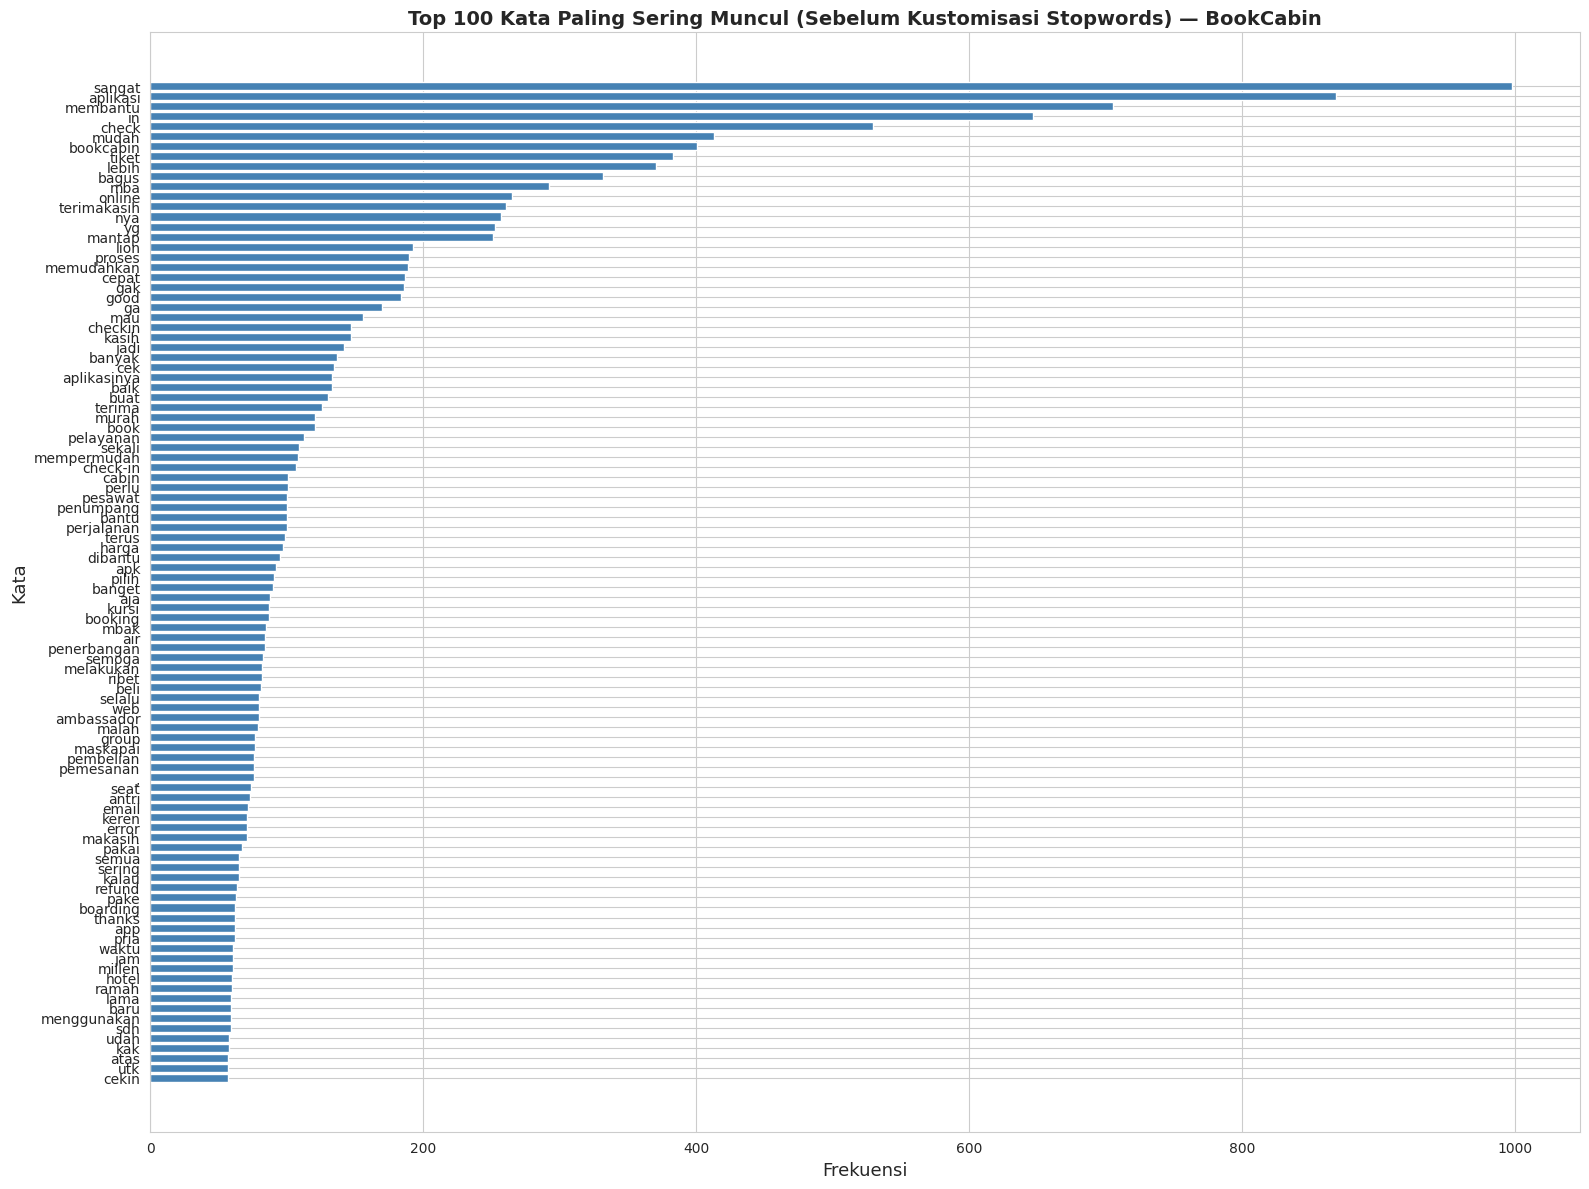

In [41]:
# Memuat daftar stopwords bahasa Indonesia dari Sastrawi
factory = StopWordRemoverFactory()
indo_stopwords = set(factory.get_stop_words())

# Verifikasi jumlah stopwords
print(f'Total stopwords Sastrawi: {len(indo_stopwords)}')
print('\n20 stopwords pertama:')
print(list(indo_stopwords)[:20])

# Gabungkan seluruh teks ulasan menjadi satu string
semua_teks = ' '.join(df_bookcabin['content'].dropna().astype(str))

# Tokenisasi dan hapus stopwords Sastrawi
kata_semua = semua_teks.lower().split()
kata_terfilter = [kata for kata in kata_semua if kata not in indo_stopwords]

# Hitung frekuensi
frekuensi_kata = Counter(kata_terfilter)
kata_umum = frekuensi_kata.most_common(100)

# Konversi ke DataFrame
df_frekuensi = pd.DataFrame(kata_umum, columns=['Kata', 'Frekuensi'])
display(df_frekuensi)

# Visualisasi
plt.figure(figsize=(16, 12))
plt.barh(df_frekuensi['Kata'][::-1], df_frekuensi['Frekuensi'][::-1], color='steelblue')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata', fontsize=13)
plt.title('Top 100 Kata Paling Sering Muncul (Sebelum Kustomisasi Stopwords) — BookCabin',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# Kata-kata yang sering muncul namun tidak memiliki
# nilai sentimen ditambahkan ke dalam daftar stopwords

custom_stopwords = [
    # 1. Istilah domain aplikasi travel/booking (BookCabin)
    'aplikasi', 'bookcabin', 'app', 'fitur', 'tiket', 'pesan',
    'pesawat', 'booking', 'maskapai', 'penerbangan', 'jadwal', 'rute',
    'bandara', 'refund', 'check-in', 'boarding', 'online',
    'offline', 'premium', 'iklan', 'ads', 'free', 'gratis', 'langganan',
    'update', 'versi', 'instal', 'masuk', 'daftar', 'akun',

    # 2. Kata kerja & kata umum netral
    'bisa', 'mau', 'perlu', 'pakai', 'pake', 'dengar', 'denger',
    'putar', 'stel', 'coba', 'kasih', 'bilang', 'minta', 'lagi',
    'udah', 'sudah', 'belum', 'kalau', 'kalo', 'ada', 'adalah',
    'adanya', 'adapun', 'aja', 'banget', 'terlalu',

    # 3. Kata ganti & kata seru
    'saya', 'aku', 'gue', 'gw', 'kamu', 'anda',
    'nya', 'si', 'min', 'admin', 'kak', 'bang',
    'nih', 'tuh', 'aja', 'deh', 'dong', 'sih',
    'yah', 'wah', 'aduh', 'oke', 'ok', 'ya',

    # 4. Kata waktu & kuantitas
    'hari', 'minggu', 'bulan', 'tahun', 'lama',
    'cepat', 'kali', 'jam', 'menit', 'detik',
    'pertama', 'kedua', 'terakhir', 'sering', 'selalu',

    # 5. Simbol & residu tanda baca
    'amp', '&', '.', ',', '-', '!', '?', '...',
    '1', '2', '3', '4', '5',
]

# Gabungkan stopwords Sastrawi dengan custom stopwords
indo_stopwords.update(custom_stopwords)

print(f'Total stopwords setelah kustomisasi: {len(indo_stopwords)}')


Total stopwords setelah kustomisasi: 220


In [43]:
indo_stopwords

{'!',
 '&',
 ',',
 '-',
 '.',
 '...',
 '1',
 '2',
 '3',
 '4',
 '5',
 '?',
 'ada',
 'adalah',
 'adanya',
 'adapun',
 'admin',
 'ads',
 'aduh',
 'agak',
 'agar',
 'aja',
 'akan',
 'aku',
 'akun',
 'amat',
 'amp',
 'anda',
 'antara',
 'anu',
 'apakah',
 'apalagi',
 'aplikasi',
 'app',
 'atau',
 'bagaimanapun',
 'bagi',
 'bahwa',
 'bandara',
 'bang',
 'banget',
 'begitu',
 'belum',
 'bilang',
 'bisa',
 'boarding',
 'boleh',
 'bookcabin',
 'booking',
 'bulan',
 'cepat',
 'check-in',
 'coba',
 'daftar',
 'dahulu',
 'dalam',
 'dan',
 'dapat',
 'dari',
 'daripada',
 'deh',
 'demi',
 'demikian',
 'dengan',
 'dengar',
 'denger',
 'detik',
 'di',
 'dia',
 'dimana',
 'dll',
 'dong',
 'dsb',
 'dst',
 'dua',
 'dulunya',
 'fitur',
 'free',
 'gratis',
 'gue',
 'guna',
 'gw',
 'hal',
 'hanya',
 'hari',
 'harus',
 'ia',
 'iklan',
 'ingin',
 'ini',
 'instal',
 'itu',
 'itulah',
 'jadwal',
 'jam',
 'jika',
 'juga',
 'kah',
 'kak',
 'kalau',
 'kali',
 'kalo',
 'kami',
 'kamu',
 'karena',
 'kasih',
 'ke',
 

=== TOP 100 KATA SETELAH PEMBERSIHAN ===
[('sangat', 998), ('membantu', 706), ('check', 530), ('mudah', 413), ('lebih', 371), ('bagus', 332), ('mba', 292), ('terimakasih', 261), ('mantap', 251), ('lion', 193), ('proses', 190), ('memudahkan', 189), ('gak', 186), ('good', 184), ('checkin', 147), ('jadi', 142), ('banyak', 137), ('cek', 135), ('aplikasinya', 133), ('baik', 133), ('buat', 130), ('terima', 126), ('murah', 121), ('book', 121), ('pelayanan', 113), ('sekali', 109), ('mempermudah', 108), ('cabin', 101), ('penumpang', 100), ('bantu', 100), ('perjalanan', 100), ('terus', 99), ('harga', 97), ('dibantu', 95), ('apk', 92), ('pilih', 91), ('kursi', 87), ('mbak', 85), ('air', 84), ('semoga', 83), ('melakukan', 82), ('ribet', 82), ('beli', 81), ('web', 80), ('ambassador', 80), ('malah', 79), ('group', 77), ('pembelian', 76), ('pemesanan', 76), ('seat', 74), ('antri', 73), ('email', 72), ('keren', 71), ('error', 71), ('makasih', 71), ('semua', 65), ('thanks', 62), ('pria', 62), ('waktu',

,Kata,Frekuensi
0,sangat,998
1,membantu,706
2,check,530
3,mudah,413
4,lebih,371
...,...,...
95,devi,40
96,pass,39
97,upgrade,39
98,tdk,38


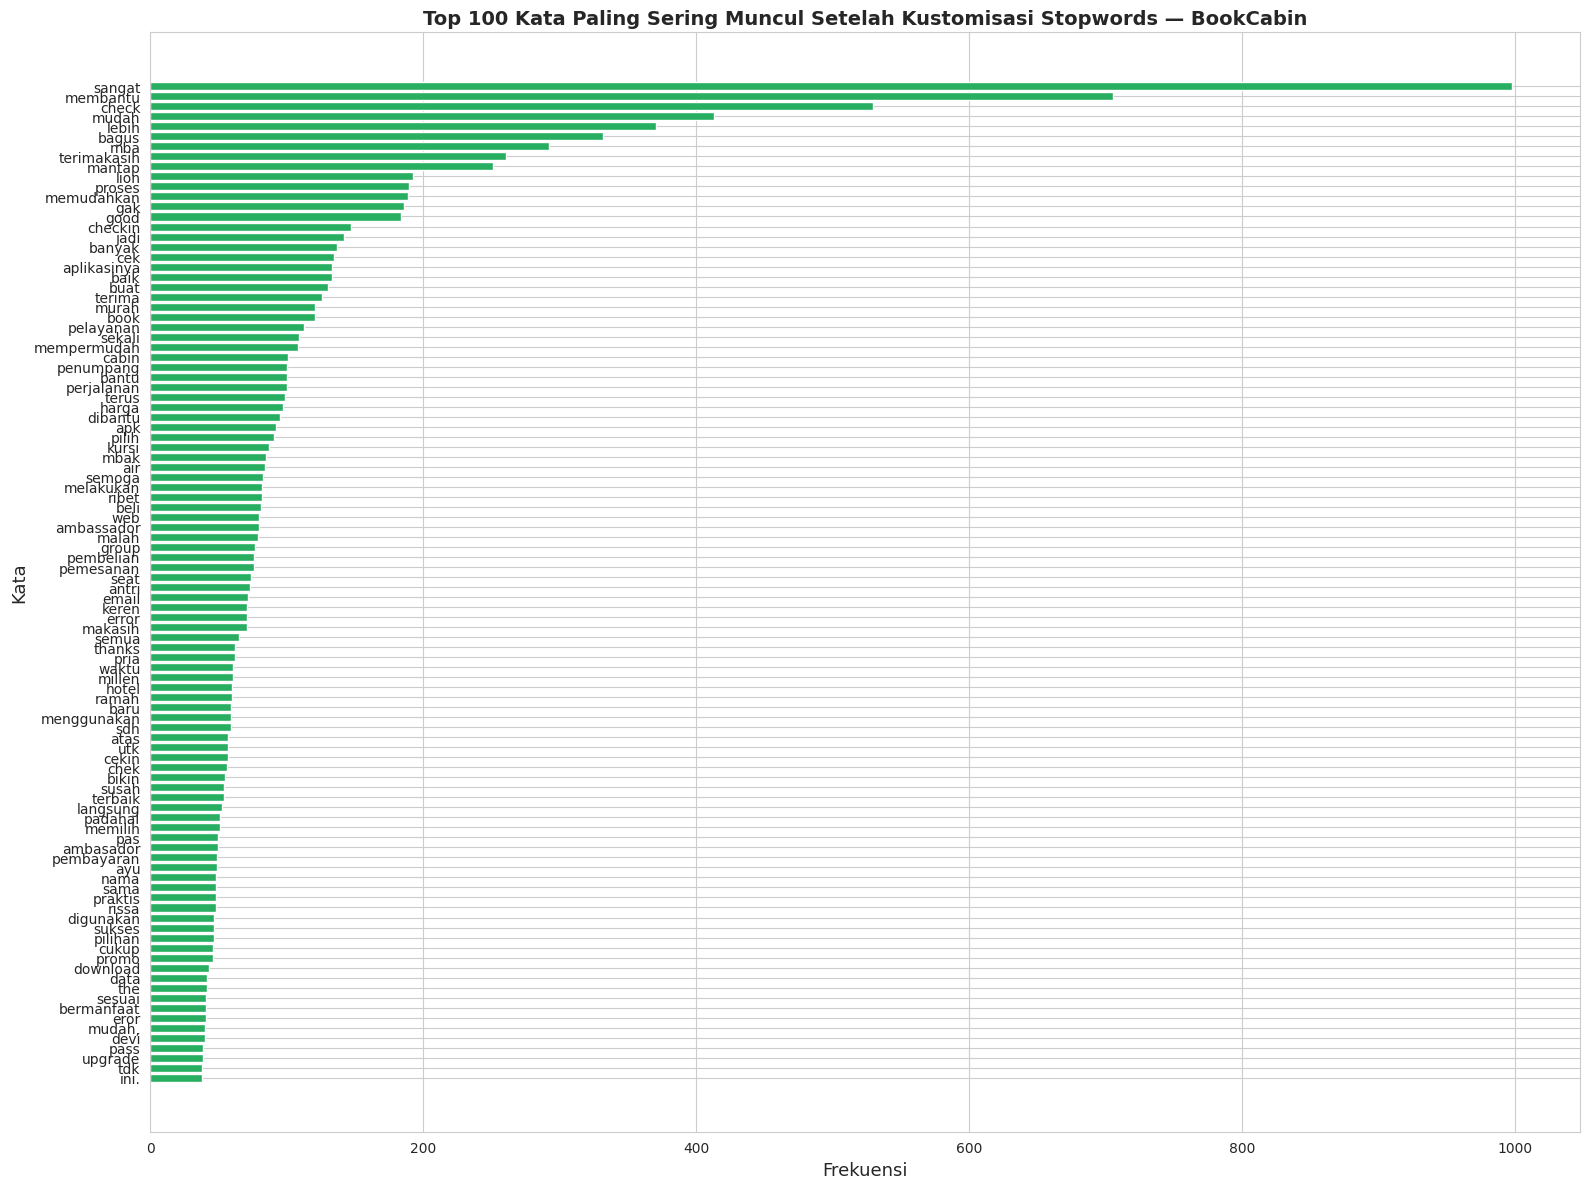

In [44]:
# Tokenisasi ulang dengan stopwords yang telah dikustomisasi
kata_bersih = [kata for kata in kata_semua if kata not in indo_stopwords and len(kata) > 2]

# Hitung frekuensi kata bersih
frekuensi_bersih = Counter(kata_bersih)
kata_umum_bersih = frekuensi_bersih.most_common(100)

# Konversi ke DataFrame
df_frekuensi_bersih = pd.DataFrame(kata_umum_bersih, columns=['Kata', 'Frekuensi'])

print('=== TOP 100 KATA SETELAH PEMBERSIHAN ===')
print(kata_umum_bersih)
display(df_frekuensi_bersih)

# Visualisasi
plt.figure(figsize=(16, 12))
plt.barh(df_frekuensi_bersih['Kata'][::-1], df_frekuensi_bersih['Frekuensi'][::-1],
         color='#27ae60', edgecolor='white')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata', fontsize=13)
plt.title('Top 100 Kata Paling Sering Muncul Setelah Kustomisasi Stopwords — BookCabin',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Stemming

,Kata Dasar,Frekuensi
0,bantu,1027
1,sangat,1005
2,mudah,852
3,check,533
4,bagus,398
5,lebih,379
6,baik,300
7,mba,297
8,mantap,274
9,terimakasih,267


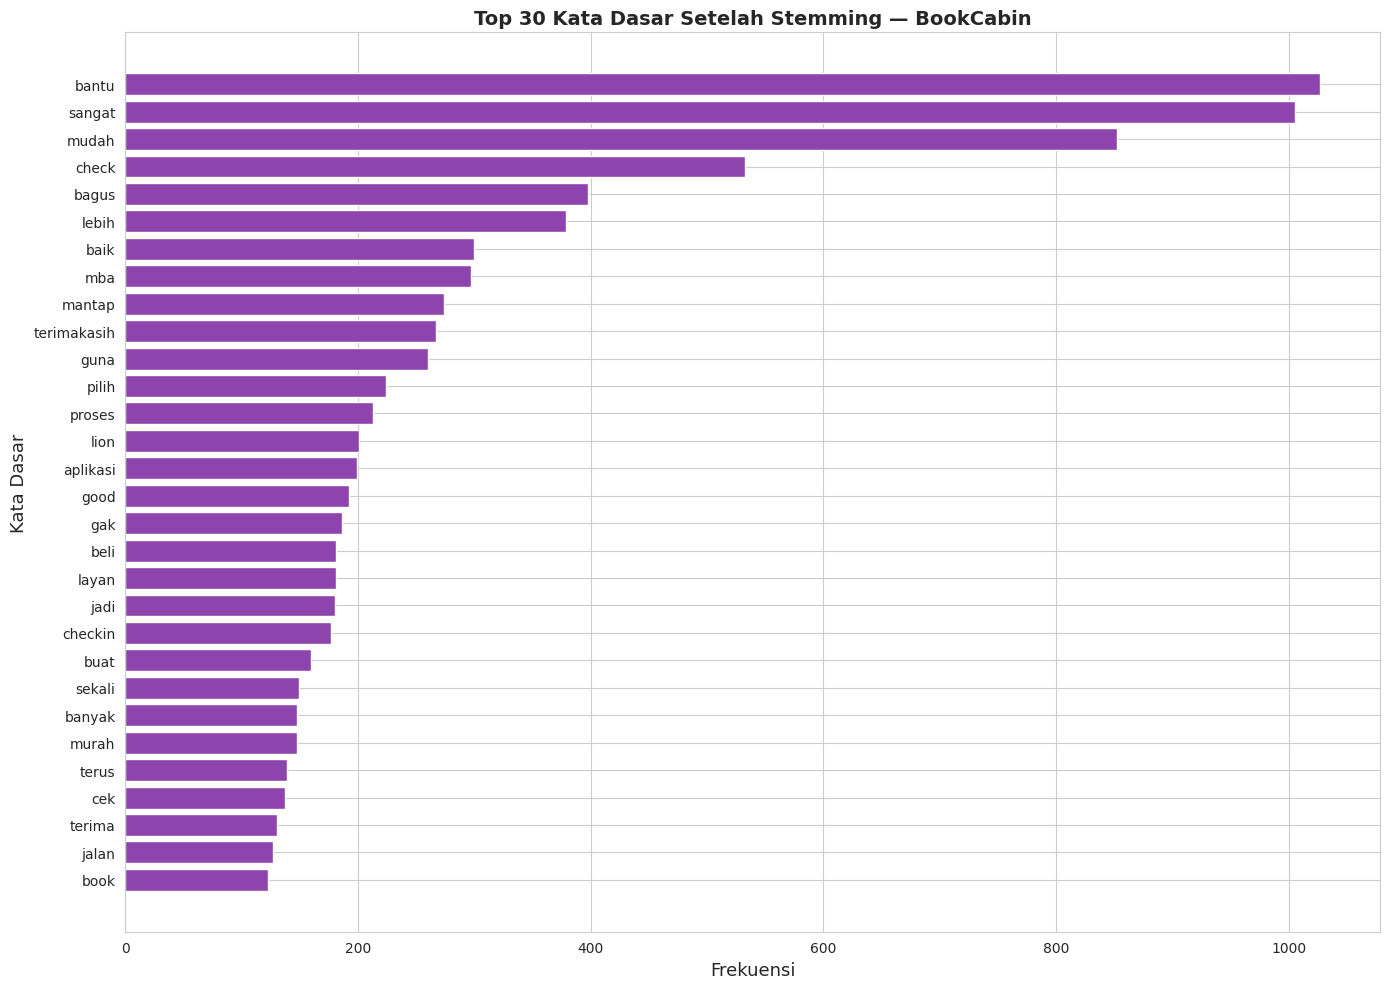

In [45]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

# Stemming seluruh kata bersih
kata_stemmed = [stemmer.stem(kata) for kata in kata_bersih]

# Hitung frekuensi setelah stemming
frekuensi_stemmed = Counter(kata_stemmed)
kata_umum_stemmed = frekuensi_stemmed.most_common(100)

df_stemmed_freq = pd.DataFrame(kata_umum_stemmed, columns=['Kata Dasar', 'Frekuensi'])
display(df_stemmed_freq.head(20))

# Visualisasi top 30 kata dasar
top30 = df_stemmed_freq.head(30)
plt.figure(figsize=(14, 10))
plt.barh(top30['Kata Dasar'][::-1], top30['Frekuensi'][::-1],
         color='#8e44ad', edgecolor='white')
plt.xlabel('Frekuensi', fontsize=13)
plt.ylabel('Kata Dasar', fontsize=13)
plt.title('Top 30 Kata Dasar Setelah Stemming — BookCabin',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Preprocessing

Konfigurasi tambahan untuk analisis sentimen dan visualisasi lanjutan

In [46]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

In [47]:
file_path = '/content/bookcabin_reviews.csv'

df_bookcabin = pd.read_csv(file_path, low_memory=False)
print(f'✅ Dataset berhasil dimuat: {len(df_bookcabin):,} baris')
display(df_bookcabin.head())

✅ Dataset berhasil dimuat: 4,170 baris


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,fb60aaa9-0dfe-431a-ae8b-b8c8c0c3a937,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"applikasi terlalu banyak bug, untuk apa adanya...",1,0,6.5.3,2026-04-30 16:02:00,NaN,NaN,6.5.3
1,b4990d01-39f0-43ec-a231-eef344873098,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Respon Customer Care sangat mengecewakan,1,0,6.5.1,2026-04-30 05:47:15,NaN,NaN,6.5.1
2,76f6ed6a-1f02-4282-855f-916a3c99a0ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,scam. penipu. beli tiket sudah brasil malah ga...,1,0,NaN,2026-04-29 04:52:42,NaN,NaN,NaN
3,371dd53e-fa03-4842-9d9b-509e3c7c8f55,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sy sudah mengajukan refund, tapi kenapa masih ...",1,0,6.5.2,2026-04-29 01:37:42,NaN,NaN,6.5.2
4,0625c812-0f16-435b-a11d-72e95ab9ae2d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong untuk rute Berau(BEJ)-Surabaya(SUB) bel...,5,0,6.5.2,2026-04-28 12:03:09,NaN,NaN,6.5.2


In [48]:
df_bookcabin['at'] = pd.to_datetime(df_bookcabin['at'])
df_bookcabin.info()

#Cek missing values
df_bookcabin.isnull().sum()

# Hapus kolom metadata yang tidak dibutuhkan dalam analisis sentimen
df_bookcabin = df_bookcabin.drop(columns=['userName', 'userImage'])

# Hapus baris yang kolom ulasannya kosong
df_bookcabin = df_bookcabin.dropna(subset=['content'])

# Isi nilai kosong pada kolom balasan dengan label 'Tidak Ada Balasan'
df_bookcabin['replyContent'] = df_bookcabin['replyContent'].fillna('Tidak Ada Balasan')
df_bookcabin['repliedAt']    = df_bookcabin['repliedAt'].fillna('Tidak Ada Balasan')
df_bookcabin['reviewCreatedVersion']    = df_bookcabin['reviewCreatedVersion'].fillna('Null')
df_bookcabin['appVersion']    = df_bookcabin['appVersion'].fillna('Null')


print('=== MISSING VALUES SETELAH PEMBERSIHAN ===')
print(df_bookcabin.isnull().sum())
print(f'\nJumlah ulasan tersisa: {len(df_bookcabin):,}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4170 entries, 0 to 4169
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              4170 non-null   object        
 1   userName              4170 non-null   object        
 2   userImage             4170 non-null   object        
 3   content               4170 non-null   object        
 4   score                 4170 non-null   int64         
 5   thumbsUpCount         4170 non-null   int64         
 6   reviewCreatedVersion  3681 non-null   object        
 7   at                    4170 non-null   datetime64[ns]
 8   replyContent          1 non-null      object        
 9   repliedAt             1 non-null      object        
 10  appVersion            3681 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 358.5+ KB
=== MISSING VALUES SETELAH PEMBERSIHAN ===
reviewId                0

In [49]:
# Polaritas dan subjektivitas dihitung sebagai fitur kuantitatif pendahuluan sebelum pemodelan menggunakan TextBlob

df_bookcabin['sentiment_polarity']   = df_bookcabin['content'].astype(str).apply(
    lambda x: TextBlob(x).polarity)
df_bookcabin['sentiment_subjective'] = df_bookcabin['content'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity)

# Labeling berdasarkan skor rating
df_bookcabin['sentiment_rating'] = df_bookcabin['score'].apply(
    lambda x: 'Positif' if x > 3 else ('Netral' if x == 3 else 'Negatif'))

df_bookcabin.loc[:, ['content', 'score',
                    'sentiment_polarity', 'sentiment_subjective',
                    'sentiment_rating']].head()

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"applikasi terlalu banyak bug, untuk apa adanya...",1,0.0625,0.5,Negatif
1,Respon Customer Care sangat mengecewakan,1,0.0000,0.0,Negatif
2,scam. penipu. beli tiket sudah brasil malah ga...,1,0.0000,0.0,Negatif
3,"sy sudah mengajukan refund, tapi kenapa masih ...",1,0.0000,0.0,Negatif
4,tolong untuk rute Berau(BEJ)-Surabaya(SUB) bel...,5,0.0000,0.0,Positif


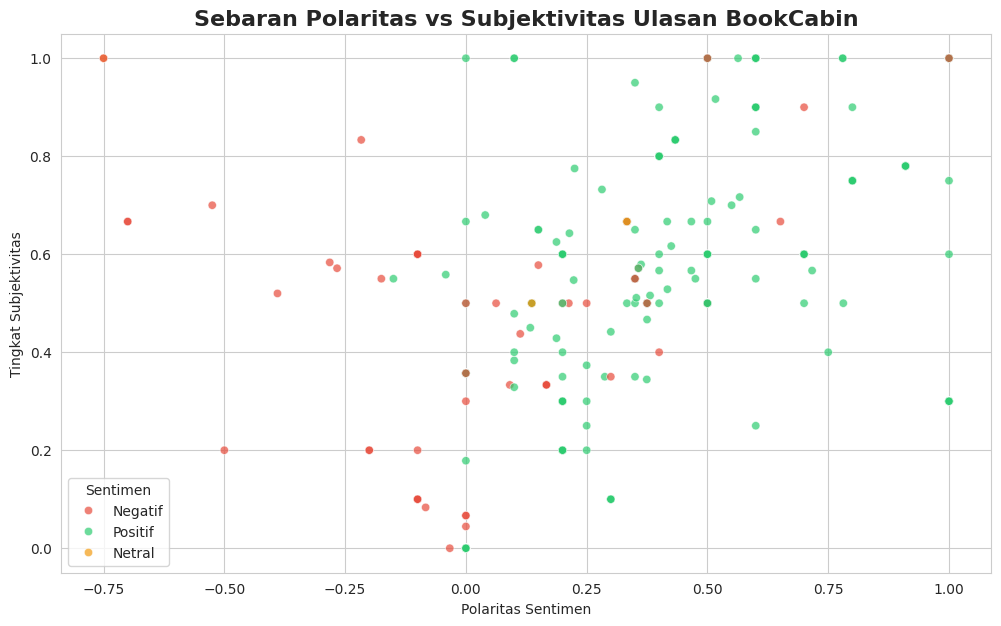

In [50]:
# Scatter plot polarity vs subjectivity
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=df_bookcabin['sentiment_polarity'],
    y=df_bookcabin['sentiment_subjective'],
    hue=df_bookcabin['sentiment_rating'],
    palette={'Positif': '#2ecc71', 'Netral': '#f39c12', 'Negatif': '#e74c3c'},
    edgecolor='white', alpha=0.7
)
plt.title('Sebaran Polaritas vs Subjektivitas Ulasan BookCabin',
          fontsize=16, fontweight='bold')
plt.xlabel('Polaritas Sentimen')
plt.ylabel('Tingkat Subjektivitas')
plt.legend(title='Sentimen')
plt.show()

Tokenization

In [51]:
# Setiap kalimat ulasan dipecah menjadi satuan kata tunggal (token)

def lakukan_tokenisasi(teks):
    return word_tokenize(str(teks))

df_bookcabin['token_awal'] = df_bookcabin['content'].apply(lakukan_tokenisasi)

display(df_bookcabin[['content', 'token_awal']].head())

,content,token_awal
0,"applikasi terlalu banyak bug, untuk apa adanya...","[applikasi, terlalu, banyak, bug, ,, untuk, ap..."
1,Respon Customer Care sangat mengecewakan,"[Respon, Customer, Care, sangat, mengecewakan]"
2,scam. penipu. beli tiket sudah brasil malah ga...,"[scam, ., penipu, ., beli, tiket, sudah, brasi..."
3,"sy sudah mengajukan refund, tapi kenapa masih ...","[sy, sudah, mengajukan, refund, ,, tapi, kenap..."
4,tolong untuk rute Berau(BEJ)-Surabaya(SUB) bel...,"[tolong, untuk, rute, Berau, (, BEJ, ), -Surab..."


In [52]:
def ubah_ke_huruf_kecil(tokens):
    return [t.lower() for t in tokens]

df_bookcabin['token_lowercase'] = df_bookcabin['token_awal'].apply(ubah_ke_huruf_kecil)

display(df_bookcabin[['token_awal', 'token_lowercase']].head())

,token_awal,token_lowercase
0,"[applikasi, terlalu, banyak, bug, ,, untuk, ap...","[applikasi, terlalu, banyak, bug, ,, untuk, ap..."
1,"[Respon, Customer, Care, sangat, mengecewakan]","[respon, customer, care, sangat, mengecewakan]"
2,"[scam, ., penipu, ., beli, tiket, sudah, brasi...","[scam, ., penipu, ., beli, tiket, sudah, brasi..."
3,"[sy, sudah, mengajukan, refund, ,, tapi, kenap...","[sy, sudah, mengajukan, refund, ,, tapi, kenap..."
4,"[tolong, untuk, rute, Berau, (, BEJ, ), -Surab...","[tolong, untuk, rute, berau, (, bej, ), -surab..."


In [53]:
kamus_slang = {
    # Negasi
    'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'ngga': 'tidak',
    'nggak': 'tidak', 'ndak': 'tidak', 'kagak': 'tidak', 'kaga': 'tidak',
    'gaada': 'tidak ada', 'gabisa': 'tidak bisa', 'gamau': 'tidak mau',
    'gajelas': 'tidak jelas', 'gajel': 'tidak jelas',

    # Kata umum & Penghubung
    'yg': 'yang', 'udh': 'sudah', 'udah': 'sudah', 'tp': 'tapi',
    'kalo': 'kalau', 'klo': 'kalau', 'jd': 'jadi', 'krn': 'karena',
    'utk': 'untuk', 'jg': 'juga', 'dr': 'dari', 'dgn': 'dengan',
    'sm': 'sama', 'aja': 'saja', 'aj': 'saja', 'dah': 'sudah',
    'sdh': 'sudah', 'tapi': 'tapi', 'biar': 'supaya', 'kayak': 'seperti',
    'kyk': 'seperti', 'kek': 'seperti', 'bgt': 'sekali', 'bngt': 'sekali',
    'banget': 'sekali', 'emang': 'memang', 'emg': 'memang',

    # Kata ganti & Sapaan
    'sy': 'saya', 'gue': 'saya', 'gw': 'saya', 'aku': 'saya',
    'lu': 'kamu', 'lo': 'kamu', 'elu': 'kamu', 'ente': 'kamu',
    'min': 'admin', 'minn': 'admin', 'kak': 'kakak', 'kk': 'kakak',

    # Istilah Umum Aplikasi
    'apk': 'aplikasi', 'hp': 'handphone', 'pake': 'pakai',
    'pakek': 'pakai', 'dl': 'download', 'unduh': 'download',
    'subs': 'langganan', 'prem': 'premium',
    'preman': 'premium', 'ads': 'iklan', 'iklanya': 'iklannya',
    'update': 'perbarui', 'updet': 'perbarui', 'instal': 'pasang',

    # Keluhan Teknis & Emosi
    'lemot': 'lambat', 'lelet': 'lambat', 'eror': 'error',
    'error': 'error', 'bug': 'gangguan', 'ngebug': 'gangguan',
    'lag': 'macet', 'ngelag': 'macet', 'fc': 'force close',
    'keluar': 'keluar sendiri', 'ribet': 'rumit', 'nyesel': 'menyesal',
    'kecewa': 'kecewa', 'parah': 'buruk', 'jelek': 'buruk',
    'mantap': 'bagus', 'mantul': 'bagus', 'oke': 'bagus',
    'sip': 'bagus', 'gud': 'bagus', 'good': 'bagus',

    # Waktu & Lainnya
    'skrg': 'sekarang', 'skrng': 'sekarang', 'trs': 'terus',
    'trus': 'terus', 'mulu': 'terus menerus', 'sering': 'sering',
    'sll': 'selalu', 'dulu': 'dulu', 'dlu': 'dulu',
    'pas': 'ketika', 'kapan': 'kapan', 'recomended': 'rekomendasi',
}

def normalisasi_slang(tokens):
    return [kamus_slang.get(token, token) for token in tokens]

df_bookcabin['token_normalisasi'] = df_bookcabin['token_lowercase'].apply(normalisasi_slang)

display(df_bookcabin[['token_lowercase', 'token_normalisasi']].head())

,token_lowercase,token_normalisasi
0,"[applikasi, terlalu, banyak, bug, ,, untuk, ap...","[applikasi, terlalu, banyak, gangguan, ,, untu..."
1,"[respon, customer, care, sangat, mengecewakan]","[respon, customer, care, sangat, mengecewakan]"
2,"[scam, ., penipu, ., beli, tiket, sudah, brasi...","[scam, ., penipu, ., beli, tiket, sudah, brasi..."
3,"[sy, sudah, mengajukan, refund, ,, tapi, kenap...","[saya, sudah, mengajukan, refund, ,, tapi, ken..."
4,"[tolong, untuk, rute, berau, (, bej, ), -surab...","[tolong, untuk, rute, berau, (, bej, ), -surab..."


In [54]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_sastrawi = set(factory.get_stop_words())

# Kata negasi & emosi yang WAJIB dipertahankan (jangan dihapus)
# 'banget' dipertahankan karena sering memperkuat sentimen (intensifier)
# 'gak'/'tidak' dipertahankan agar tidak mengubah makna
kata_penting = {'tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'kurang', 'gak', 'ga', 'nggak'}

# `indo_stopwords` sudah berisi stopwords Sastrawi dan custom stopwords BookCabin dari sel sebelumnya.
# Jadi, kita bisa langsung menggunakannya di sini.

# Gabungkan: indo_stopwords (Sastrawi + Custom BookCabin) - Kata Penting
stopwords_final = indo_stopwords - kata_penting # Use indo_stopwords directly

def hapus_stopwords(tokens):
    return [
        token for token in tokens
        # Token harus tidak ada di list stopword DAN panjangnya lebih dari 2
        # (kecuali untuk kata penting seperti 'ga')
        if (token not in stopwords_final and len(token) > 2) or token in kata_penting
    ]

# Jalankan pembersihan
df_bookcabin['token_bersih'] = df_bookcabin['token_normalisasi'].apply(hapus_stopwords)

# Statistik
total_sebelum = df_bookcabin['token_normalisasi'].apply(len).sum()
total_sesudah = df_bookcabin['token_bersih'].apply(len).sum()
reduksi = (total_sebelum - total_sesudah) / total_sebelum * 100

print(f'Total token sebelum  : {total_sebelum:,}')
print(f'Total token sesudah  : {total_sesudah:,}')
print(f'Persentase reduksi   : {reduksi:.2f}%')
print(f'Total stopwords aktif: {len(stopwords_final)}')

display(df_bookcabin[['token_normalisasi', 'token_bersih']].head())

Total token sebelum  : 46,515
Total token sesudah  : 26,512
Persentase reduksi   : 43.00%
Total stopwords aktif: 216


,token_normalisasi,token_bersih
0,"[applikasi, terlalu, banyak, gangguan, ,, untu...","[applikasi, banyak, gangguan, apa, applikasi, ..."
1,"[respon, customer, care, sangat, mengecewakan]","[respon, customer, care, sangat, mengecewakan]"
2,"[scam, ., penipu, ., beli, tiket, sudah, brasi...","[scam, penipu, beli, brasil, malah, gagal, sal..."
3,"[saya, sudah, mengajukan, refund, ,, tapi, ken...","[mengajukan, proses, peninjauan, padahal, supe..."
4,"[tolong, untuk, rute, berau, (, bej, ), -surab...","[berau, bej, -surabaya, sub, belum]"


In [55]:
stemmer_factory = StemmerFactory()
stemmer_id = stemmer_factory.create_stemmer()

def lakukan_stemming(tokens):
    kalimat = ' '.join(tokens)
    return stemmer_id.stem(kalimat).split()

df_bookcabin['token_stemmed'] = df_bookcabin['token_bersih'].apply(lakukan_stemming)

# Statistik perubahan
total_sebelum_stem = df_bookcabin['token_bersih'].apply(len).sum()
total_sesudah_stem = df_bookcabin['token_stemmed'].apply(len).sum()

print(f'Total token sebelum stemming: {total_sebelum_stem:,}')
print(f'Total token sesudah stemming: {total_sesudah_stem:,}')

display(df_bookcabin[['token_bersih', 'token_stemmed']].head())

Total token sebelum stemming: 26,512
Total token sesudah stemming: 26,562


,token_bersih,token_stemmed
0,"[applikasi, banyak, gangguan, apa, applikasi, ...","[applikasi, banyak, ganggu, apa, applikasi, ti..."
1,"[respon, customer, care, sangat, mengecewakan]","[respon, customer, care, sangat, kecewa]"
2,"[scam, penipu, beli, brasil, malah, gagal, sal...","[scam, tipu, beli, brasil, malah, gagal, saldo..."
3,"[mengajukan, proses, peninjauan, padahal, supe...","[aju, proses, tinjau, padahal, superjet, pihak..."
4,"[berau, bej, -surabaya, sub, belum]","[rau, bej, -surabaya, sub, belum]"


In [56]:
def hapus_tanda_baca(tokens):
    return [
        token for token in tokens
        if token not in string.punctuation and token.strip() != ''
    ]

df_bookcabin['token_tanpa_punctuation'] = df_bookcabin['token_stemmed'].apply(hapus_tanda_baca)

display(df_bookcabin[['token_stemmed', 'token_tanpa_punctuation']].head())

,token_stemmed,token_tanpa_punctuation
0,"[applikasi, banyak, ganggu, apa, applikasi, ti...","[applikasi, banyak, ganggu, apa, applikasi, ti..."
1,"[respon, customer, care, sangat, kecewa]","[respon, customer, care, sangat, kecewa]"
2,"[scam, tipu, beli, brasil, malah, gagal, saldo...","[scam, tipu, beli, brasil, malah, gagal, saldo..."
3,"[aju, proses, tinjau, padahal, superjet, pihak...","[aju, proses, tinjau, padahal, superjet, pihak..."
4,"[rau, bej, -surabaya, sub, belum]","[rau, bej, -surabaya, sub, belum]"


In [57]:
# Kata dengan frekuensi sangat rendah (< 5 kali) dibuang karena tidak memiliki kekuatan statistik

frekuensi_semua_kata = Counter(
    kata for tokens in df_bookcabin['token_tanpa_punctuation']
    for kata in tokens
)

ambang_batas = 5
kata_langka = {kata for kata, jumlah in frekuensi_semua_kata.items() if jumlah < ambang_batas}

def hapus_kata_langka(tokens):
    return [kata for kata in tokens if kata not in kata_langka]

df_bookcabin['token_final'] = df_bookcabin['token_tanpa_punctuation'].apply(hapus_kata_langka)

df_perubahan = df_bookcabin[
    df_bookcabin['token_tanpa_punctuation'].astype(str) != df_bookcabin['token_final'].astype(str)
]

print(f'Jumlah kata langka ditemukan  : {len(kata_langka):,}')
print(f'Jumlah ulasan terdampak       : {len(df_perubahan):,}')
display(df_perubahan[['token_tanpa_punctuation', 'token_final']].head())

Jumlah kata langka ditemukan  : 2,705
Jumlah ulasan terdampak       : 1,596


,token_tanpa_punctuation,token_final
0,"[applikasi, banyak, ganggu, apa, applikasi, ti...","[applikasi, banyak, ganggu, apa, applikasi, ti..."
1,"[respon, customer, care, sangat, kecewa]","[respon, customer, sangat, kecewa]"
2,"[scam, tipu, beli, brasil, malah, gagal, saldo...","[tipu, beli, malah, gagal, tdk]"
3,"[aju, proses, tinjau, padahal, superjet, pihak...","[aju, proses, padahal, pihak, batal, semua]"
4,"[rau, bej, -surabaya, sub, belum]",[belum]


In [58]:
baris_kosong = df_bookcabin[df_bookcabin['token_final'].apply(lambda x: len(x) == 0)]
print(f'Jumlah baris kosong ditemukan: {len(baris_kosong):,}')

df_bookcabin = df_bookcabin[df_bookcabin['token_final'].apply(lambda x: len(x) > 0)].copy()
print(f'Jumlah ulasan clear          : {len(df_bookcabin):,}')

display(df_bookcabin[['content', 'token_final']].head())

Jumlah baris kosong ditemukan: 245
Jumlah ulasan clear          : 3,925


,content,token_final
0,"applikasi terlalu banyak bug, untuk apa adanya...","[applikasi, banyak, ganggu, apa, applikasi, ti..."
1,Respon Customer Care sangat mengecewakan,"[respon, customer, sangat, kecewa]"
2,scam. penipu. beli tiket sudah brasil malah ga...,"[tipu, beli, malah, gagal, tdk]"
3,"sy sudah mengajukan refund, tapi kenapa masih ...","[aju, proses, padahal, pihak, batal, semua]"
4,tolong untuk rute Berau(BEJ)-Surabaya(SUB) bel...,[belum]


In [59]:
df_bookcabin['content_bersih'] = df_bookcabin['token_final'].apply(lambda x: ' '.join(x))

# Hitung ulang polarity dari teks yang sudah bersih
df_bookcabin['sentiment_polarity']   = df_bookcabin['content_bersih'].astype(str).apply(
    lambda x: TextBlob(x).polarity)
df_bookcabin['sentiment_subjective'] = df_bookcabin['content_bersih'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity)
df_bookcabin['sentiment_rating'] = df_bookcabin['score'].apply(
    lambda x: 'Positif' if x > 3 else ('Netral' if x == 3 else 'Negatif'))

display(df_bookcabin[['content_bersih', 'score',
                    'sentiment_polarity', 'sentiment_subjective',
                    'sentiment_rating']].head())

,content_bersih,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,applikasi banyak ganggu apa applikasi tidak gu...,1,0.0,0.0,Negatif
1,respon customer sangat kecewa,1,0.0,0.0,Negatif
2,tipu beli malah gagal tdk,1,0.0,0.0,Negatif
3,aju proses padahal pihak batal semua,1,0.0,0.0,Negatif
4,belum,5,0.0,0.0,Positif


# Final Dataset

In [60]:
df_bersih = df_bookcabin.copy()

kolom_buang = [
    'token_awal', 'token_lowercase', 'token_normalisasi',
    'token_bersih', 'token_stemmed', 'token_tanpa_punctuation',
    'token_final'
]
df_bersih = df_bersih.drop(columns=kolom_buang)

display(df_bersih.head())
df_bersih.info()

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment_polarity,sentiment_subjective,sentiment_rating,content_bersih
0,fb60aaa9-0dfe-431a-ae8b-b8c8c0c3a937,"applikasi terlalu banyak bug, untuk apa adanya...",1,0,6.5.3,2026-04-30 16:02:00,Tidak Ada Balasan,Tidak Ada Balasan,6.5.3,0.0,0.0,Negatif,applikasi banyak ganggu apa applikasi tidak gu...
1,b4990d01-39f0-43ec-a231-eef344873098,Respon Customer Care sangat mengecewakan,1,0,6.5.1,2026-04-30 05:47:15,Tidak Ada Balasan,Tidak Ada Balasan,6.5.1,0.0,0.0,Negatif,respon customer sangat kecewa
2,76f6ed6a-1f02-4282-855f-916a3c99a0ea,scam. penipu. beli tiket sudah brasil malah ga...,1,0,Null,2026-04-29 04:52:42,Tidak Ada Balasan,Tidak Ada Balasan,Null,0.0,0.0,Negatif,tipu beli malah gagal tdk
3,371dd53e-fa03-4842-9d9b-509e3c7c8f55,"sy sudah mengajukan refund, tapi kenapa masih ...",1,0,6.5.2,2026-04-29 01:37:42,Tidak Ada Balasan,Tidak Ada Balasan,6.5.2,0.0,0.0,Negatif,aju proses padahal pihak batal semua
4,0625c812-0f16-435b-a11d-72e95ab9ae2d,tolong untuk rute Berau(BEJ)-Surabaya(SUB) bel...,5,0,6.5.2,2026-04-28 12:03:09,Tidak Ada Balasan,Tidak Ada Balasan,6.5.2,0.0,0.0,Positif,belum


<class 'pandas.core.frame.DataFrame'>
Index: 3925 entries, 0 to 4169
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              3925 non-null   object        
 1   content               3925 non-null   object        
 2   score                 3925 non-null   int64         
 3   thumbsUpCount         3925 non-null   int64         
 4   reviewCreatedVersion  3925 non-null   object        
 5   at                    3925 non-null   datetime64[ns]
 6   replyContent          3925 non-null   object        
 7   repliedAt             3925 non-null   object        
 8   appVersion            3925 non-null   object        
 9   sentiment_polarity    3925 non-null   float64       
 10  sentiment_subjective  3925 non-null   float64       
 11  sentiment_rating      3925 non-null   object        
 12  content_bersih        3925 non-null   object        
dtypes: datetime64[ns](1), f

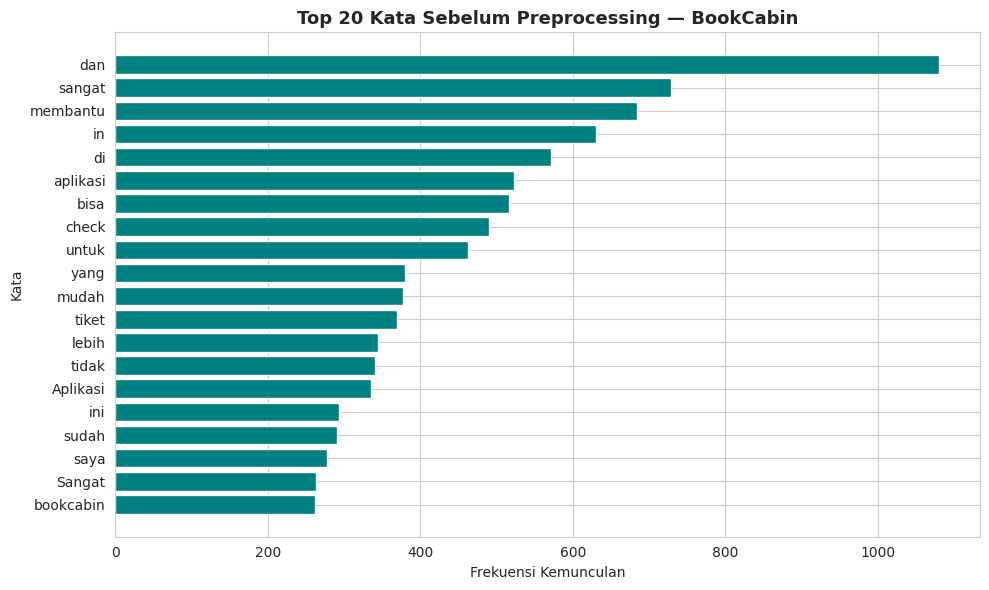

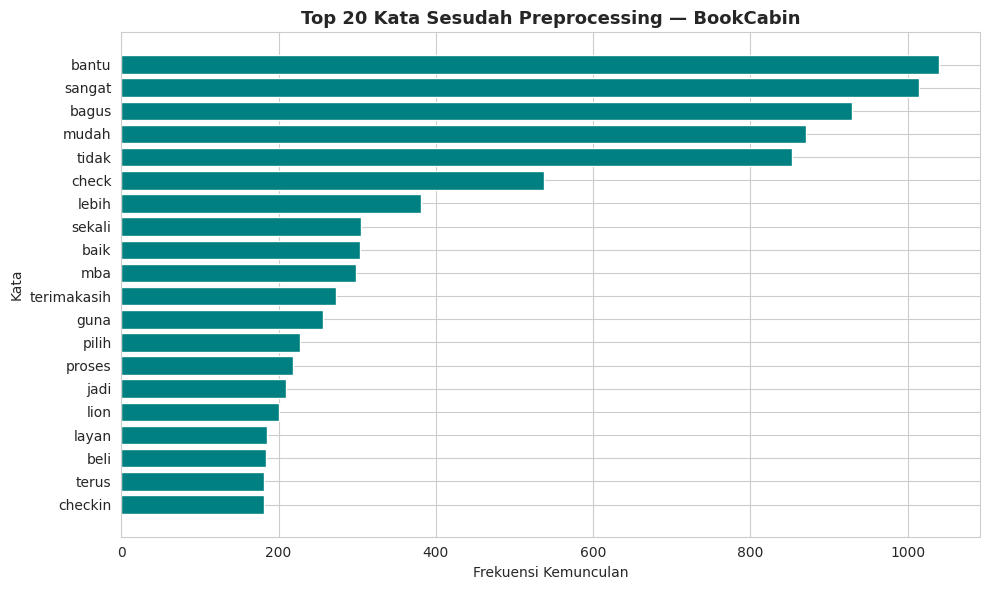

In [61]:
def tampilkan_frekuensi(seri_teks, judul):
    semua_kata = ' '.join(seri_teks.dropna().astype(str)).split()
    frekuensi = Counter(semua_kata)
    top_20 = frekuensi.most_common(20)
    df_top = pd.DataFrame(top_20, columns=['Kata', 'Frekuensi'])

    plt.figure(figsize=(10, 6))
    plt.barh(df_top['Kata'][::-1], df_top['Frekuensi'][::-1], color='teal')
    plt.xlabel('Frekuensi Kemunculan')
    plt.ylabel('Kata')
    plt.title(judul, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Sebelum preprocessing
tampilkan_frekuensi(df_bookcabin['content'],
                    'Top 20 Kata Sebelum Preprocessing — BookCabin')

# Sesudah preprocessing
tampilkan_frekuensi(df_bersih['content_bersih'],
                    'Top 20 Kata Sesudah Preprocessing — BookCabin')

In [64]:
import os

output_path = '../out/cleandata_bookcabin_processed.csv' # Changed filename
output_dir = os.path.dirname(output_path)

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

df_bersih.to_csv(output_path, index=False, encoding='utf-8')

print(f'✅ Data berhasil disimpan ke: {output_path}')
print(f'   Jumlah baris : {len(df_bersih):,}')
print(f'   Jumlah kolom : {df_bersih.shape[1]}')

✅ Data berhasil disimpan ke: ../out/cleandata_bookcabin_processed.csv
   Jumlah baris : 3,925
   Jumlah kolom : 13
